<a href="https://colab.research.google.com/github/sudip328/Random-Forest-Cs2GeX6-/blob/main/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== XGBoost Training Performance ==========
RMSE = 0.0011 eV
MAE  = 0.0010 eV
R²   = 1.0000

========== XGBoost LOOCV Performance ==========
LOOCV RMSE = 2.7031 eV
LOOCV MAE  = 2.3903 eV
LOOCV R²   = -0.4634

========== LOOCV Predictions ==========


,Compound,Actual Band Gap (eV),Predicted Band Gap (eV),Absolute Error (eV)
0,Cs2GeF6,5.910,2.259120,3.650880
1,Cs2GeCl6,2.260,5.909102,3.649102
2,Cs2GeBr6,1.016,2.260008,1.244008
3,Cs2GeI6,0.000,1.017208,1.017208


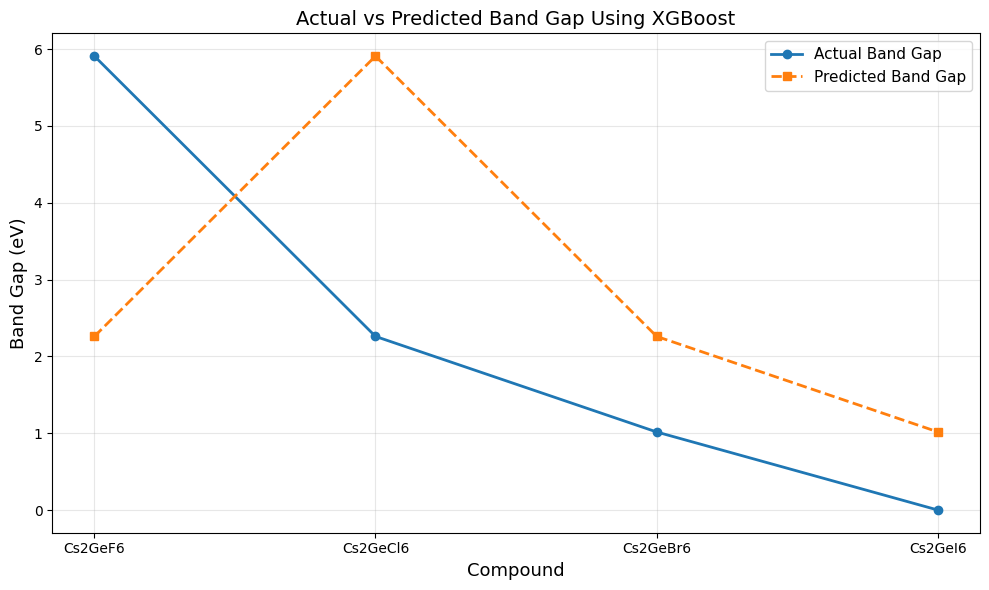

In [2]:
# ============================================================
# XGBOOST REGRESSION + LOOCV
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------------------
# 1. Dataset
# ------------------------------------------------------------

data = {
    "Compound": [
        "Cs2GeF6",
        "Cs2GeCl6",
        "Cs2GeBr6",
        "Cs2GeI6"
    ],

    "Lattice_parameter": [
        9.23, 10.59, 11.09, 11.70
    ],

    "Volume": [
        786.86, 1187.00, 1365.11, 1601.50
    ],

    "Tolerance_factor": [
        1.14, 1.05, 1.03, 1.00
    ],

    "Octahedral_factor": [
        0.398, 0.293, 0.271, 0.241
    ],

    "Formation_energy": [
        -4.78, -3.38, -2.72, -1.03
    ],

    "Band_gap": [
        5.91, 2.26, 1.016, 0.00
    ]
}

df = pd.DataFrame(data)

# ------------------------------------------------------------
# 2. Feature and target selection
# ------------------------------------------------------------

features = [
    "Lattice_parameter",
    "Volume",
    "Tolerance_factor",
    "Octahedral_factor",
    "Formation_energy"
]

target = "Band_gap"

X = df[features]
y = df[target]

# ------------------------------------------------------------
# 3. Train XGBoost model on complete dataset
# ------------------------------------------------------------

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X, y)

# Training predictions
y_train_pred = xgb_model.predict(X)

# Training metrics
train_rmse = np.sqrt(mean_squared_error(y, y_train_pred))
train_mae = mean_absolute_error(y, y_train_pred)
train_r2 = r2_score(y, y_train_pred)

print("========== XGBoost Training Performance ==========")
print(f"RMSE = {train_rmse:.4f} eV")
print(f"MAE  = {train_mae:.4f} eV")
print(f"R²   = {train_r2:.4f}")

# ------------------------------------------------------------
# 4. LOOCV
# ------------------------------------------------------------

loo = LeaveOneOut()

loo_predictions = []
loo_actual = []
loo_compounds = []

for train_index, test_index in loo.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    xgb_loo = XGBRegressor(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    xgb_loo.fit(X_train, y_train)

    prediction = xgb_loo.predict(X_test)

    loo_predictions.append(prediction[0])
    loo_actual.append(y_test.iloc[0])
    loo_compounds.append(df["Compound"].iloc[test_index[0]])

# ------------------------------------------------------------
# 5. LOOCV metrics
# ------------------------------------------------------------

loo_rmse = np.sqrt(
    mean_squared_error(loo_actual, loo_predictions)
)

loo_mae = mean_absolute_error(
    loo_actual, loo_predictions
)

loo_r2 = r2_score(
    loo_actual, loo_predictions
)

print("\n========== XGBoost LOOCV Performance ==========")
print(f"LOOCV RMSE = {loo_rmse:.4f} eV")
print(f"LOOCV MAE  = {loo_mae:.4f} eV")
print(f"LOOCV R²   = {loo_r2:.4f}")

# ------------------------------------------------------------
# 6. LOOCV results table
# ------------------------------------------------------------

xgb_results = pd.DataFrame({
    "Compound": loo_compounds,
    "Actual Band Gap (eV)": loo_actual,
    "Predicted Band Gap (eV)": loo_predictions
})

xgb_results["Absolute Error (eV)"] = abs(
    xgb_results["Actual Band Gap (eV)"] -
    xgb_results["Predicted Band Gap (eV)"]
)

print("\n========== LOOCV Predictions ==========")
display(xgb_results)

# ------------------------------------------------------------
# 7. Actual vs predicted plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    loo_compounds,
    loo_actual,
    marker='o',
    linewidth=2,
    label='Actual Band Gap'
)

plt.plot(
    loo_compounds,
    loo_predictions,
    marker='s',
    linewidth=2,
    linestyle='--',
    label='Predicted Band Gap'
)

plt.xlabel("Compound", fontsize=13)
plt.ylabel("Band Gap (eV)", fontsize=13)
plt.title("Actual vs Predicted Band Gap Using XGBoost", fontsize=14)

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()